# run_VAECF.ipynb — VAE feature extraction + classifier (Accuracy & F1)

This notebook trains a **Variational Autoencoder (VAE)** on each dataset to learn a latent representation, then fits a **classifier** on the latent features and reports **Accuracy** and **F1** (macro by default).

Datasets (5): **car**, **shuttle**, **nursery**, **adult**, **magic**.

> **Data input options**
> 1) **Local CSV files (recommended)**: put files at `data/<name>.csv`  
> 2) **OpenML fetch (optional)**: will try `sklearn.datasets.fetch_openml` if local CSV not found.

**Target column**: by default this notebook tries `["class", "target", "label", "y"]`. You can override per dataset in the `DATASETS` dict.


In [1]:
# If running in a fresh environment, you may need:
# !pip install -q numpy pandas scikit-learn torch tqdm

import os
import math
import random
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE


C:\Users\ROG\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device(type='cpu')

In [2]:
# -----------------------------
# 1) Dataset configuration
# -----------------------------

DATA_DIR = Path("data")

# You can point to your own CSVs here. If the file doesn't exist, we try OpenML.
DATASETS = {
    "car": {
        "csv": DATA_DIR / "car.csv",
        "openml_name": "car",
        "target_col": None,  # None -> auto-detect
    },
    "shuttle": {
        "csv": DATA_DIR / "shuttle.csv",
        "openml_name": "shuttle",
        "target_col": None,
    },
    "nursery": {
        "csv": DATA_DIR / "nursery.csv",
        "openml_name": "nursery",
        "target_col": None,
    },
    "adult": {
        "csv": DATA_DIR / "adult.csv",
        "openml_name": "adult",
        "target_col": None,
    },
    "magic": {
        "csv": DATA_DIR / "magic.csv",
        "openml_name": "MagicTelescope",  # common OpenML name
        "target_col": None,
    },
}

TARGET_CANDIDATES = ["class", "target", "label", "y"]


In [3]:
# -----------------------------
# 2) Data loading helpers
# -----------------------------

def _infer_target_column(df: pd.DataFrame) -> str:
    for c in TARGET_CANDIDATES:
        if c in df.columns:
            return c
    # Fallback: last column
    return df.columns[-1]

def load_dataset(name: str):
    cfg = DATASETS[name]
    csv_path = Path(cfg["csv"])

    if csv_path.exists():
        df = pd.read_csv(csv_path)
        source = f"local_csv:{csv_path.as_posix()}"
    else:
        # Optional OpenML fallback (requires internet access)
        from sklearn.datasets import fetch_openml
        Xy = fetch_openml(name=cfg["openml_name"], as_frame=True)
        df = Xy.frame.copy()
        source = f"openml:{cfg['openml_name']}"

    target_col = cfg["target_col"] or _infer_target_column(df)

    X = df.drop(columns=[target_col])
    y = df[target_col]

    # Ensure y is 1D
    if isinstance(y, pd.DataFrame):
        y = y.iloc[:, 0]

    return X, y, source, target_col

def describe_xy(X, y, name, source, target_col):
    print(f"\n{name.upper()} | source={source} | target_col={target_col}")
    print("X shape:", X.shape, " | y shape:", y.shape)
    print("y value counts (top 10):")
    print(pd.Series(y).value_counts().head(10))


In [4]:
# Quick sanity check (prints basic info for each dataset)
for ds_name in DATASETS:
    X, y, source, target_col = load_dataset(ds_name)
    describe_xy(X, y, ds_name, source, target_col)


C:\Users\ROG\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\datasets\_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name car exist. Versions may be fundamentally different, returning version 2. Available versions:
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=991
- version 3, status: active
  url: https://www.openml.org/search?type=data&id=40975

  warn(warning_msg)



CAR | source=openml:car | target_col=binaryClass
X shape: (1728, 6)  | y shape: (1728,)
y value counts (top 10):
binaryClass
P    1210
N     518
Name: count, dtype: int64

SHUTTLE | source=openml:shuttle | target_col=class
X shape: (58000, 9)  | y shape: (58000,)
y value counts (top 10):
class
1    45586
4     8903
5     3267
3      171
2       50
7       13
6       10
Name: count, dtype: int64


C:\Users\ROG\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\datasets\_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name nursery exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=26
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=959

  warn(warning_msg)



NURSERY | source=openml:nursery | target_col=class
X shape: (12960, 8)  | y shape: (12960,)
y value counts (top 10):
class
not_recom     4320
priority      4266
spec_prior    4044
very_recom     328
recommend        2
Name: count, dtype: int64


C:\Users\ROG\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\datasets\_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name adult exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=179
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=1590

  warn(warning_msg)



ADULT | source=openml:adult | target_col=class
X shape: (48842, 14)  | y shape: (48842,)
y value counts (top 10):
class
<=50K    37155
>50K     11687
Name: count, dtype: int64


C:\Users\ROG\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\datasets\_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name magictelescope exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=1120
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=43971

  warn(warning_msg)



MAGIC | source=openml:MagicTelescope | target_col=class:
X shape: (19020, 10)  | y shape: (19020,)
y value counts (top 10):
class:
g    12332
h     6688
Name: count, dtype: int64


## 3) Preprocessing (numeric + categorical → dense matrix)

We use a `ColumnTransformer`:
- **numeric**: median impute (simple) + `StandardScaler`
- **categorical**: most-frequent impute (simple) + `OneHotEncoder(handle_unknown='ignore')`

Output is a dense `float32` matrix for the VAE.


In [5]:
from sklearn.impute import SimpleImputer

def build_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in X.columns if c not in num_cols]

    numeric_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ])

    categorical_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])

    pre = ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, num_cols),
            ("cat", categorical_pipe, cat_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )
    return pre


## 4) VAE (PyTorch)

We train a small MLP VAE on the preprocessed matrix **X_train** only (unsupervised).  
Then we map samples to latent mean **μ** and train a classifier on **μ**.


In [7]:
class VAE(nn.Module):
    def __init__(self, input_dim: int, latent_dim: int = 16, hidden_dim: int = 256, dropout: float = 0.1):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.mu = nn.Linear(hidden_dim, latent_dim)
        self.logvar = nn.Linear(hidden_dim, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x)
        mu = self.mu(h)
        logvar = self.logvar(h)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decoder(z)
        return x_recon, mu, logvar


def vae_loss(x, x_recon, mu, logvar, beta: float = 1.0):
    # Reconstruction (MSE) + KL
    recon = torch.mean(torch.sum((x_recon - x) ** 2, dim=1))
    kl = torch.mean(torch.sum(-0.5 * (1 + logvar - mu.pow(2) - logvar.exp()), dim=1))
    return recon + beta * kl, recon.detach(), kl.detach()


@torch.no_grad()
def encode_mu(model: VAE, X: np.ndarray, batch_size: int = 512) -> np.ndarray:
    model.eval()
    loader = DataLoader(TensorDataset(torch.from_numpy(X)), batch_size=batch_size, shuffle=False)
    mus = []
    for (xb,) in loader:
        xb = xb.to(DEVICE)
        _, mu, _ = model(xb)
        mus.append(mu.detach().cpu().numpy())
    return np.concatenate(mus, axis=0)


def train_vae(X_train: np.ndarray, latent_dim: int = 16, hidden_dim: int = 256,
              lr: float = 1e-3, batch_size: int = 512, epochs: int = 20, beta: float = 1.0,
              dropout: float = 0.1) -> VAE:
    input_dim = X_train.shape[1]
    model = VAE(input_dim=input_dim, latent_dim=latent_dim, hidden_dim=hidden_dim, dropout=dropout).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    loader = DataLoader(TensorDataset(torch.from_numpy(X_train)), batch_size=batch_size, shuffle=True, drop_last=False)

    for ep in range(1, epochs + 1):
        model.train()
        pbar = tqdm(loader, desc=f"VAE epoch {ep}/{epochs}", leave=False)
        losses = []
        for (xb,) in pbar:
            xb = xb.to(DEVICE)
            x_recon, mu, logvar = model(xb)
            loss, recon, kl = vae_loss(xb, x_recon, mu, logvar, beta=beta)

            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()

            losses.append(loss.item())
            pbar.set_postfix(loss=np.mean(losses), recon=float(recon), kl=float(kl))
    return model


## 5) End-to-end runner (per dataset)

- Split: 80/20 train/test (stratified when possible)
- Preprocess: fit on train, transform train/test
- Train VAE on X_train_dense
- Encode μ for train/test
- Train classifier (Logistic Regression by default)
- Report:
  - **Accuracy**
  - **F1 macro** (works for binary and multi-class)


In [8]:
def safe_train_test_split(X, y, test_size=0.2, seed=SEED):
    # Stratify if y has at least 2 classes and each class has >=2 samples
    y_series = pd.Series(y)
    vc = y_series.value_counts()
    can_strat = (vc.min() >= 2) and (vc.shape[0] >= 2)
    strat = y if can_strat else None
    return train_test_split(X, y, test_size=test_size, random_state=seed, stratify=strat)

def run_one_dataset(name: str,
                    latent_dim: int = 16,
                    hidden_dim: int = 256,
                    vae_epochs: int = 20,
                    vae_beta: float = 1.0,
                    vae_lr: float = 1e-3,
                    vae_batch_size: int = 512,
                    clf_max_iter: int = 2000):
    X, y, source, target_col = load_dataset(name)

    X_train, X_test, y_train, y_test = safe_train_test_split(X, y, test_size=0.2, seed=SEED)

    pre = build_preprocessor(X_train)
    X_train_dense = pre.fit_transform(X_train).astype(np.float32)
    X_test_dense = pre.transform(X_test).astype(np.float32)

    # Train VAE on train features only
    vae = train_vae(
        X_train_dense,
        latent_dim=latent_dim,
        hidden_dim=hidden_dim,
        lr=vae_lr,
        batch_size=vae_batch_size,
        epochs=vae_epochs,
        beta=vae_beta,
        dropout=0.1,
    )

    # Latent features (mu)
    Z_train = encode_mu(vae, X_train_dense, batch_size=vae_batch_size)
    Z_test = encode_mu(vae, X_test_dense, batch_size=vae_batch_size)

    # Classifier on latent space
    clf = LogisticRegression(max_iter=clf_max_iter, n_jobs=None)  # n_jobs ignored by some solvers
    clf.fit(Z_train, y_train)

    y_pred = clf.predict(Z_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro")

    return {
        "dataset": name,
        "source": source,
        "target_col": target_col,
        "n_train": len(y_train),
        "n_test": len(y_test),
        "input_dim_after_preprocess": X_train_dense.shape[1],
        "latent_dim": latent_dim,
        "accuracy": acc,
        "f1_macro": f1,
    }


In [9]:
# -----------------------------
# 6) Run all 5 datasets and collect results
# -----------------------------

# You can tune these if training is slow:
VAE_EPOCHS = 20
LATENT_DIM = 16
HIDDEN_DIM = 256
BETA = 1.0
LR = 1e-3
BATCH = 512

results = []
for name in DATASETS.keys():
    out = run_one_dataset(
        name,
        latent_dim=LATENT_DIM,
        hidden_dim=HIDDEN_DIM,
        vae_epochs=VAE_EPOCHS,
        vae_beta=BETA,
        vae_lr=LR,
        vae_batch_size=BATCH,
        clf_max_iter=3000,
    )
    results.append(out)

results_df = pd.DataFrame(results).sort_values("dataset").reset_index(drop=True)
results_df


C:\Users\ROG\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\datasets\_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name car exist. Versions may be fundamentally different, returning version 2. Available versions:
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=991
- version 3, status: active
  url: https://www.openml.org/search?type=data&id=40975

  warn(warning_msg)
C:\Users\ROG\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\datasets\_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name nursery exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=26
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=959

  warn(warning_msg)
C:\Users\ROG\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\datasets\_

,dataset,source,target_col,n_train,n_test,input_dim_after_preprocess,latent_dim,accuracy,f1_macro
0,adult,openml:adult,class,39073,9769,121,16,0.819838,0.710184
1,car,openml:car,binaryClass,1382,346,21,16,0.699422,0.411565
2,magic,openml:MagicTelescope,class:,15216,3804,10,16,0.800473,0.762977
3,nursery,openml:nursery,class,10368,2592,27,16,0.563272,0.422048
4,shuttle,openml:shuttle,class,46400,11600,9,16,0.980431,0.632336


In [10]:
display_cols = ["dataset", "accuracy", "f1_macro", "n_train", "n_test", "input_dim_after_preprocess", "latent_dim", "source"]
results_df_display = results_df[display_cols].copy()
results_df_display["accuracy"] = results_df_display["accuracy"].round(4)
results_df_display["f1_macro"] = results_df_display["f1_macro"].round(4)
results_df_display


,dataset,accuracy,f1_macro,n_train,n_test,input_dim_after_preprocess,latent_dim,source
0,adult,0.8198,0.7102,39073,9769,121,16,openml:adult
1,car,0.6994,0.4116,1382,346,21,16,openml:car
2,magic,0.8005,0.7630,15216,3804,10,16,openml:MagicTelescope
3,nursery,0.5633,0.4220,10368,2592,27,16,openml:nursery
4,shuttle,0.9804,0.6323,46400,11600,9,16,openml:shuttle


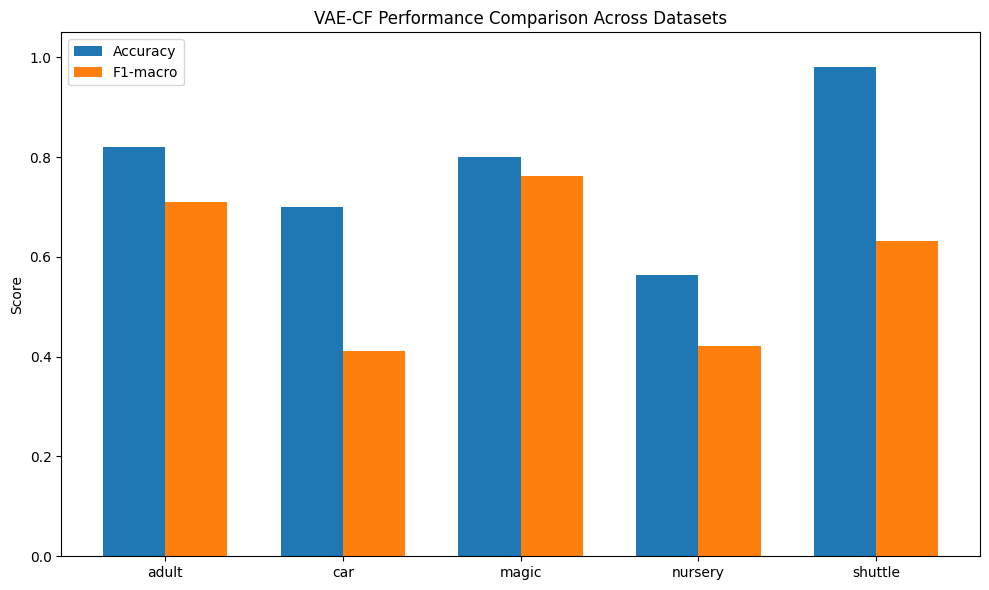

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Your results
results_df = pd.DataFrame({
    "dataset": ["adult", "car", "magic", "nursery", "shuttle"],
    "accuracy": [0.8198, 0.6994, 0.8005, 0.5633, 0.9804],
    "f1_macro": [0.7102, 0.4116, 0.7630, 0.4220, 0.6323]
})

# Bar positions
x = np.arange(len(results_df))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(x - width/2, results_df["accuracy"], width, label="Accuracy")
plt.bar(x + width/2, results_df["f1_macro"], width, label="F1-macro")

plt.xticks(x, results_df["dataset"])
plt.ylabel("Score")
plt.title("VAE-CF Performance Comparison Across Datasets")
plt.legend()

plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()
